In [19]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from collections import Counter
import random
import numpy as np
from pathlib import Path

In [21]:
# -----------------------------
# 1. Sample corpus
# -----------------------------

#corpus = [
#    "A mother loves her child",
#    "A father loves his child",
#    "Parents care for their children",
#    "A mother and father are parents",
#    "Children love their mother",
#    "Children love their father",
#]

#prepare the data
!python prep_fairytales.py --indir ./raw_fairytales --outdir corpus --lower --dedup

Loaded raw_fairytales\7439-h.htm
{
  "stories": 1,
  "tokens": 61026,
  "vocab": 5658,
  "removed_non_english": 0,
  "generated_at": "2026-02-12T11:06:47.870151Z"
}
✔ Wrote 1 stories to corpus\clean


In [22]:
# -----------------------------
# 2. Preprocessing
# -----------------------------
#def tokenize_corpus(corpus): old corpus tokenizer
#    tokens = [sentence.lower().split() for sentence in corpus]
#    return tokens

def iter_tokens(tokens_path: Path):
    with tokens_path.open("r", encoding="utf-8") as f:
        for line in f:
            yield line.strip().split()

In [23]:
tokens_path = Path('.\\corpus\\clean\\corpus.txt')
tokenized_corpus = list(iter_tokens(tokens_path))

#tokenized_corpus = tokenize_corpus(corpus) ## old corpus tokenizer
vocab = Counter([word for sentence in tokenized_corpus for word in sentence])
word2idx = {word: idx for idx, (word, _) in enumerate(vocab.items())}
idx2word = {idx: word for word, idx in word2idx.items()}
vocab_size = len(word2idx)

In [24]:
word2idx

{'text': 0,
 'file': 1,
 'produced': 2,
 'by': 3,
 'charles': 4,
 'franks,': 5,
 'delphine': 6,
 'lettau': 7,
 'and': 8,
 'the': 9,
 'people': 10,
 'at': 11,
 'dp': 12,
 'html': 13,
 'david': 14,
 'widger': 15,
 'english': 16,
 'fairy': 17,
 'tales': 18,
 'anonymous': 19,
 'collected': 20,
 'joseph': 21,
 'jacobs': 22,
 'how': 23,
 'to': 24,
 'get': 25,
 'into': 26,
 'this': 27,
 'book.': 28,
 'knock': 29,
 'knocker': 30,
 'on': 31,
 'door,': 32,
 'pull': 33,
 'bell': 34,
 'side,': 35,
 'then,': 36,
 'if': 37,
 'you': 38,
 'are': 39,
 'very': 40,
 'quiet,': 41,
 'will': 42,
 'hear': 43,
 'a': 44,
 'teeny': 45,
 'tiny': 46,
 'voice': 47,
 'say': 48,
 'through': 49,
 'grating': 50,
 '"take': 51,
 'down': 52,
 'key."': 53,
 'find': 54,
 'back:': 55,
 'cannot': 56,
 'mistake': 57,
 'it,': 58,
 'for': 59,
 'it': 60,
 'has': 61,
 'j.': 62,
 'in': 63,
 'wards.': 64,
 'put': 65,
 'key': 66,
 'keyhole,': 67,
 'which': 68,
 'fits': 69,
 'exactly,': 70,
 'unlock': 71,
 'door': 72,
 'walk': 73,
 '

In [25]:
vocab_size

9147

In [26]:
vocab

Counter({'the': 4056,
         'and': 3134,
         'to': 1611,
         'a': 1306,
         'of': 1230,
         'he': 1068,
         'in': 815,
         'was': 706,
         'she': 680,
         'his': 646,
         'that': 533,
         'it': 503,
         'her': 461,
         'for': 445,
         'you': 434,
         'with': 430,
         'so': 410,
         'as': 398,
         'they': 391,
         'i': 379,
         'on': 375,
         'but': 375,
         'at': 325,
         'had': 311,
         'said': 309,
         'is': 282,
         'all': 276,
         'him': 273,
         'went': 270,
         'be': 264,
         'my': 245,
         'when': 243,
         'by': 240,
         'have': 233,
         'little': 227,
         'up': 217,
         'then': 212,
         'out': 209,
         'not': 209,
         'came': 205,
         'this': 194,
         'down': 183,
         'one': 181,
         'there': 181,
         ',': 177,
         'jack': 164,
         'into': 158,
         

In [73]:
# -----------------------------
# 3. Generate training data (Skip-gram)
# -----------------------------
def generate_skipgram_data(tokenized_corpus,direction='left', window_size=2):
    lists_words = []
    lists_indexes = []
    for sentence in tokenized_corpus:
        for center_idx, center_word in enumerate(sentence):
            if direction == 'both':
                context_range = range(max(0, center_idx - window_size//2), min(len(sentence), center_idx + window_size//2 + 1))
            elif direction == 'left':
                if center_idx <= window_size - 1:
                    continue
                context_range = range(max(0, center_idx - window_size), center_idx)
            elif direction == 'right':
                if center_idx >= len(sentence) - window_size:
                    continue
                context_range = range(center_idx + 1, min(len(sentence), center_idx + window_size+ 1))
            context_list = [center_word]
            context_id_list = [word2idx[center_word]]
            for context_idx in context_range:
                if context_idx != center_idx:
                    context_list.append(sentence[context_idx])
                    context_id_list.append(word2idx[sentence[context_idx]])
            lists_words.append(tuple(context_list)) 
            lists_indexes.append(tuple(context_id_list))
    return lists_words, lists_indexes

lists_words,lists_indexes  = generate_skipgram_data(tokenized_corpus,window_size=4,direction='left')

In [74]:
lists_words

[('charles', 'text', 'file', 'produced', 'by'),
 ('franks,', 'file', 'produced', 'by', 'charles'),
 ('delphine', 'produced', 'by', 'charles', 'franks,'),
 ('lettau', 'by', 'charles', 'franks,', 'delphine'),
 ('and', 'charles', 'franks,', 'delphine', 'lettau'),
 ('the', 'franks,', 'delphine', 'lettau', 'and'),
 ('people', 'delphine', 'lettau', 'and', 'the'),
 ('at', 'lettau', 'and', 'the', 'people'),
 ('dp', 'and', 'the', 'people', 'at'),
 ('html', 'the', 'people', 'at', 'dp'),
 ('file', 'people', 'at', 'dp', 'html'),
 ('produced', 'at', 'dp', 'html', 'file'),
 ('by', 'dp', 'html', 'file', 'produced'),
 ('david', 'html', 'file', 'produced', 'by'),
 ('widger', 'file', 'produced', 'by', 'david'),
 ('english', 'produced', 'by', 'david', 'widger'),
 ('fairy', 'by', 'david', 'widger', 'english'),
 ('tales', 'david', 'widger', 'english', 'fairy'),
 ('by', 'widger', 'english', 'fairy', 'tales'),
 ('anonymous', 'english', 'fairy', 'tales', 'by'),
 ('collected', 'fairy', 'tales', 'by', 'anonymou

In [75]:
lists_indexes

[(4, 0, 1, 2, 3),
 (5, 1, 2, 3, 4),
 (6, 2, 3, 4, 5),
 (7, 3, 4, 5, 6),
 (8, 4, 5, 6, 7),
 (9, 5, 6, 7, 8),
 (10, 6, 7, 8, 9),
 (11, 7, 8, 9, 10),
 (12, 8, 9, 10, 11),
 (13, 9, 10, 11, 12),
 (1, 10, 11, 12, 13),
 (2, 11, 12, 13, 1),
 (3, 12, 13, 1, 2),
 (14, 13, 1, 2, 3),
 (15, 1, 2, 3, 14),
 (16, 2, 3, 14, 15),
 (17, 3, 14, 15, 16),
 (18, 14, 15, 16, 17),
 (3, 15, 16, 17, 18),
 (19, 16, 17, 18, 3),
 (20, 17, 18, 3, 19),
 (3, 18, 3, 19, 20),
 (21, 3, 19, 20, 3),
 (22, 19, 20, 3, 21),
 (23, 20, 3, 21, 22),
 (24, 3, 21, 22, 23),
 (25, 21, 22, 23, 24),
 (26, 22, 23, 24, 25),
 (27, 23, 24, 25, 26),
 (28, 24, 25, 26, 27),
 (29, 25, 26, 27, 28),
 (11, 26, 27, 28, 29),
 (9, 27, 28, 29, 11),
 (30, 28, 29, 11, 9),
 (31, 29, 11, 9, 30),
 (9, 11, 9, 30, 31),
 (32, 9, 30, 31, 9),
 (33, 30, 31, 9, 32),
 (9, 31, 9, 32, 33),
 (34, 9, 32, 33, 9),
 (11, 32, 33, 9, 34),
 (9, 33, 9, 34, 11),
 (35, 9, 34, 11, 9),
 (36, 34, 11, 9, 35),
 (37, 11, 9, 35, 36),
 (38, 9, 35, 36, 37),
 (39, 35, 36, 37, 38),
 (40

In [76]:
# -----------------------------
# 4. Negative Sampling
# -----------------------------
def get_negative_samples(pos_batch, num_negatives=5):
    neg_samples = []
    #random.seed(0)
    while len(neg_samples) < num_negatives:
        neg = random.randint(0, vocab_size - 1)
        if neg not in pos_batch:
            neg_samples.append(neg)
    return neg_samples

In [14]:
# -----------------------------
# 5. Word2Vec Model
# -----------------------------
class Word2Vec(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super(Word2Vec, self).__init__()
        #torch.manual_seed(0)
        self.in_embed = nn.Embedding(vocab_size, embedding_dim)
        self.out_embed = nn.Embedding(vocab_size, embedding_dim)

    def forward(self, center_words, pos_context, neg_context):
        center_embeds = self.in_embed(center_words)
        pos_embeds = self.out_embed(pos_context)
        neg_embeds = self.out_embed(neg_context) 

        avg_pos_embeds = torch.mean(pos_embeds, dim=1, keepdim=True)
        
        # Positive score
        pos_score = F.cosine_similarity(avg_pos_embeds.squeeze(0), center_embeds.unsqueeze(1), dim=2)
        pos_loss = torch.log(torch.sigmoid(pos_score) + 1e-10)

        # Negative score
        neg_score = F.cosine_similarity(neg_embeds, center_embeds.unsqueeze(1), dim=2)
        neg_loss = torch.log(1-torch.sigmoid(neg_score) + 1e-10)

        return -(pos_loss.mean()+neg_loss.mean())/2

    def get_in_embeddings(self):
        return self.in_embed.weight.data.cpu()
    def get_out_embeddings(self):
        return self.out_embed.weight.data.cpu()

In [78]:
### Example just two batches for demonstration in excel

embedding_dim = 4
model = Word2Vec(vocab_size, embedding_dim)
optimizer = optim.Adam(model.parameters(), lr=0.01)

epochs = 1
batch_size = 3
num_negatives = 2


total_loss = 0

for i in range(0,2):
    batch = lists_indexes[i:i+batch_size]
    print("batch: ",str(i))
    print(batch)
    center_batch = torch.LongTensor([t[0] for t in batch])
    pos_batch = torch.LongTensor([t[0] if len(t)==2 else t[1:len(t)] for t in batch])
    neg_batch = torch.LongTensor([get_negative_samples(t[0] if len(t)==2 else t[1:len(t)], num_negatives) for t in batch])

    embedings_in = model.get_in_embeddings()
    embedings_out = model.get_out_embeddings()

    optimizer.zero_grad()

    center_embeds = embedings_in[center_batch]
    pos_embeds = embedings_out[pos_batch]
    avg_pos_embeds = torch.mean(pos_embeds, dim=1, keepdim=True) 
    neg_embeds = embedings_out[neg_batch] 
    
    print("center_batch:",center_batch.tolist())
    print(center_embeds)
    print("pos_batch:",pos_batch.tolist())
    print(pos_embeds)
    print("avg_pos_embeds:")
    print(avg_pos_embeds)
    print("neg_batch:",neg_batch.tolist())
    print(neg_embeds)

    loss = model(center_batch, pos_batch, neg_batch)
    loss.backward()
    optimizer.step()
    total_loss += loss.item()

    print("pos_model")
    print("center_batch:",model.get_in_embeddings()[center_batch])
    print(embedings_in[center_batch])
    print("pos_batch:",pos_batch)
    print(embedings_out[pos_batch])
    print("neg_batch:",neg_batch)
    print(embedings_out[neg_batch])

    print("loss:",loss)
    

batch:  0
[(4, 0, 1, 2, 3), (5, 1, 2, 3, 4), (6, 2, 3, 4, 5)]
center_batch: [4, 5, 6]
tensor([[-0.2995,  0.1376,  0.3520,  0.3197],
        [-0.0138, -1.1932,  0.3437,  0.7320],
        [ 1.0443, -0.9590, -0.5594, -0.9827]])
pos_batch: [[0, 1, 2, 3], [1, 2, 3, 4], [2, 3, 4, 5]]
tensor([[[ 2.7271, -0.8747,  0.5019,  0.1569],
         [ 0.7063,  0.1465,  0.8723, -0.3109],
         [-0.2129, -0.2179,  0.3873,  0.9030],
         [ 0.0114, -1.2768, -0.6166,  0.6721]],

        [[ 0.7063,  0.1465,  0.8723, -0.3109],
         [-0.2129, -0.2179,  0.3873,  0.9030],
         [ 0.0114, -1.2768, -0.6166,  0.6721],
         [-0.1428,  1.5728, -0.4705,  0.6751]],

        [[-0.2129, -0.2179,  0.3873,  0.9030],
         [ 0.0114, -1.2768, -0.6166,  0.6721],
         [-0.1428,  1.5728, -0.4705,  0.6751],
         [ 0.5604, -0.5150, -1.4396, -2.1056]]])
avg_pos_embeds:
tensor([[[ 0.8080, -0.5557,  0.2862,  0.3552]],

        [[ 0.0905,  0.0562,  0.0431,  0.4848]],

        [[ 0.0540, -0.1092, -0.5348, 

In [79]:
# -----------------------------
# 6. Training
# -----------------------------

embedding_dim = 200
model = Word2Vec(vocab_size, embedding_dim)
optimizer = optim.Adam(model.parameters(), lr=0.01)

epochs = 50
batch_size = 50
num_negatives = 2

epoch_loss = []

for epoch in range(epochs):
    print("Epoch:",epoch+1)
    total_loss = 0
    random.shuffle(lists_indexes)
    for i in range(0, len(lists_indexes), batch_size):
        batch = lists_indexes[i:i+batch_size]
        center_batch = torch.LongTensor([t[0] for t in batch])
        pos_batch = torch.LongTensor([t[0] if len(t)==2 else t[1:len(t)] for t in batch])
        neg_batch = torch.LongTensor([get_negative_samples(t[0] if len(t)==2 else t[1:len(t)], num_negatives) for t in batch])

        optimizer.zero_grad()
        loss = model(center_batch, pos_batch, neg_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    epoch_loss.append(total_loss)

    
    print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss:.4f}")
torch.save(model, "word2vect_tania.pt")

Epoch: 1
Epoch 1/50, Loss: 743.6222
Epoch: 2
Epoch 2/50, Loss: 575.6769
Epoch: 3
Epoch 3/50, Loss: 483.9998
Epoch: 4
Epoch 4/50, Loss: 441.4557
Epoch: 5
Epoch 5/50, Loss: 424.2710
Epoch: 6
Epoch 6/50, Loss: 415.9108
Epoch: 7
Epoch 7/50, Loss: 411.9601
Epoch: 8
Epoch 8/50, Loss: 408.8110
Epoch: 9
Epoch 9/50, Loss: 406.9077
Epoch: 10
Epoch 10/50, Loss: 406.1222
Epoch: 11
Epoch 11/50, Loss: 405.5292
Epoch: 12
Epoch 12/50, Loss: 405.2592
Epoch: 13
Epoch 13/50, Loss: 404.5335
Epoch: 14
Epoch 14/50, Loss: 404.8000
Epoch: 15
Epoch 15/50, Loss: 404.4159
Epoch: 16
Epoch 16/50, Loss: 404.1842
Epoch: 17
Epoch 17/50, Loss: 404.3776
Epoch: 18
Epoch 18/50, Loss: 404.1370
Epoch: 19
Epoch 19/50, Loss: 404.3978
Epoch: 20
Epoch 20/50, Loss: 404.1019
Epoch: 21
Epoch 21/50, Loss: 404.0992
Epoch: 22
Epoch 22/50, Loss: 404.1212
Epoch: 23
Epoch 23/50, Loss: 403.8574
Epoch: 24
Epoch 24/50, Loss: 404.3348
Epoch: 25
Epoch 25/50, Loss: 403.7304
Epoch: 26
Epoch 26/50, Loss: 404.1148
Epoch: 27
Epoch 27/50, Loss: 4

Text(0.5, 1.0, 'Training Loss Curve')

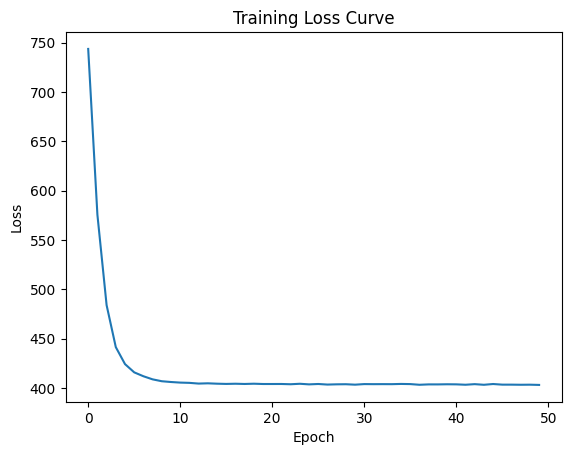

In [80]:
#plotting the loss curve
import matplotlib.pyplot as plt
plt.plot(epoch_loss)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Curve')

In [50]:
model = torch.load("word2vect_tania.pt",map_location="cpu",weights_only=False)

In [112]:
embeddings = model.get_in_embeddings()

def find_similar_embedding(positive, negative, top_n=5):
    positive_negative = positive + negative
    cos = nn.CosineSimilarity(dim=0, eps=1e-6)

    for item in positive_negative:
        if item not in word2idx:
            print(f"{item} not in vocabulary")

    query_vec = embeddings[word2idx[positive[0]]] - embeddings[word2idx[negative[0]]] + embeddings[word2idx[positive[1]]]
    
    # Compute cosine similarity with all other words
    similarities = {}
    for word, idx in word2idx.items():
        if word not in positive_negative:
            
            sim = cos(query_vec,embeddings[idx])
            similarities[word] = sim
    
    # Sort by similarity
    similar_words = sorted(similarities.items(), key=lambda x: x[1], reverse=True)[:top_n]
    
    print(f"\nTop {top_n} words similar to embedding:")
    for word, score in similar_words:
        print(f"{word}: {score:.4f}")

In [120]:
find_similar_embedding(positive = ['king','woman'], negative = ['man'], top_n=5)


Top 5 words similar to embedding:
child,: 0.9995
some: 0.9995
golden: 0.9995
mouse: 0.9994
brother: 0.9994


In [27]:
# -----------------------------
# 7. View learned embeddings for some words
# -----------------------------

#embeddings = model.get_embeddings()
#for word, idx in word2idx.items():
#    print(f"{word}: {embeddings[idx]}")

embeddings = model.get_in_embeddings()
# Example: Get embedding for a specific word
words = ["father","mother"]
for word in words:
    if word in word2idx:
        word_idx = word2idx[word]
        embedding_vector = embeddings[word_idx]
        print(f"Embedding for '{word}': {embedding_vector}")


Embedding for 'father': tensor([ 2.4710, -0.9623,  2.3008,  2.7400, -1.9369, -2.4962, -1.7440, -2.3928,
         2.4602, -1.9649,  2.1570, -1.7819,  2.5563,  0.1689,  2.5306,  2.3020,
         2.7738, -2.8148,  1.3965,  0.8099, -2.5723, -2.3308, -2.3388,  0.9181,
         2.7762,  2.6041,  2.5410, -2.3812,  1.8226,  1.6725, -0.1915, -2.3257,
        -1.9742, -2.7129, -2.4585, -1.4851,  1.4953,  2.5211, -1.6092,  1.9400,
         2.3538,  0.7707, -2.4231, -2.7103,  1.2174, -0.6412, -2.3234,  1.9085,
         1.4805,  2.7634,  0.4921,  2.2966, -2.3126, -2.5697,  1.7440,  2.2036,
         1.9968,  2.2885,  2.3699, -2.5823, -1.7727, -2.6734,  2.9860, -2.4946,
        -1.4580, -2.5578, -2.5655, -2.0686,  2.3425,  2.5514, -1.0649, -2.0214,
        -2.2508,  1.4691, -2.6820,  2.4054, -2.3159,  2.4586, -2.4605,  0.1111,
         1.6334, -0.1274, -2.2209, -2.8723, -2.6926,  2.5045, -2.1715, -2.5002,
         2.4151, -2.4819, -2.3580, -1.7539,  2.5709,  0.5216,  2.7815, -2.2790,
         2.5997,

In [36]:
# -----------------------------
# 8. Compute distance between two word embeddings
# -----------------------------

def euclidean_distance_manual(vec1, vec2):
    """
    Calculate Euclidean distance between two vectors.

    Parameters:
    -----------
    vec1, vec2 : numpy arrays
        The vectors to compare

    Returns:
    --------
    float
        Euclidean distance (lower means more similar)
    """
    # np.linalg.norm computes the square root of sum of squared differences
    # This implements the Euclidean distance formula directly
    return np.linalg.norm(vec1 - vec2)
    
def dot_product_similarity_manual(vec1, vec2):
    """
    Calculate dot product between two vectors.

    Parameters:
    -----------
    vec1, vec2 : numpy arrays
        The vectors to compare

    Returns:
    --------
    float
        Dot product score (higher means more similar)
    """
    # np.dot multiplies corresponding elements and sums them
    # This directly implements the dot product formula
    return np.dot(vec1, vec2)

def cosine_similarity_manual(vec1, vec2):
    """
    Calculate cosine similarity between two vectors.

    Parameters:
    -----------
    vec1, vec2 : numpy arrays
        The vectors to compare

    Returns:
    --------
    float
        Cosine similarity score between -1 and 1
    """
    # Calculate dot product (numerator)
    dot_product = np.dot(vec1, vec2)

    # Calculate magnitudes using np.linalg.norm (denominator)
    # np.linalg.norm computes sqrt(sum of squared values)
    magnitude1 = np.linalg.norm(vec1)
    magnitude2 = np.linalg.norm(vec2)

    # Divide dot product by product of magnitudes
    similarity = dot_product / (magnitude1 * magnitude2)

    return similarity


In [117]:
from numpy.linalg import norm
cos = nn.CosineSimilarity(dim=0, eps=1e-6)

def find_similar_words(query_word, top_n=5):
    if query_word not in word2idx:
        print(f"'{query_word}' not in vocabulary.")
        return
    
    # Get the embedding for the query word
    query_idx = word2idx[query_word]
    query_vec = embeddings[query_idx]
    
    # Compute cosine similarity with all other words
    similarities = {}
    for word, idx in word2idx.items():
        if word != query_word:
            sim = cos(query_vec,embeddings[idx])
            similarities[word] = sim
    
    # Sort by similarity
    similar_words = sorted(similarities.items(), key=lambda x: x[1], reverse=True)[:top_n]
    
    print(f"\nTop {top_n} words similar to '{query_word}':")
    for word, score in similar_words:
        print(f"{word}: {score:.4f}")


In [121]:
# Example usage:
find_similar_words("king", top_n=4)


Top 4 words similar to 'king':
some: 0.9998
golden: 0.9998
sick: 0.9998
him,: 0.9998


In [ ]:
import matplotlib.pyplot as plt
x_coords, y_coords = zip(*[model.get_in_embeddings()[word2idx[word]] for word in word2idx])

plt.figure(figsize=(10, 8))
plt.scatter(x_coords, y_coords, marker='o', color='blue')

for i, word in enumerate(list(word2idx)):
    plt.annotate(word, (x_coords[i], y_coords[i]), textcoords="offset points", xytext=(0, 5), ha='center')

plt.title('Word Embeddings')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.xlim(-2, 2)
plt.ylim(-2, 2)
plt.grid(True)
plt.show()